# World Bank Africa Infrastructure Project Cost Predictor
## Mission: Develop software solutions that help African governments avoid corruption and public property exploitation

### Problem Statement
Governments and oversight bodies across Africa struggle to anticipate the true final cost of World Bank-funded infrastructure projects. This model predicts the **actual total project cost (USD)** from pre-approval features — giving procurement agencies and anti-corruption units a tool to flag projects where costs are likely to balloon far beyond the World Bank's initial commitment, a common indicator of budget misuse.

### Dataset
- **Source**: World Bank Projects & Operations — official dataset published by The World Bank on Kaggle
- **Link**: https://www.kaggle.com/datasets/theworldbank/world-bank-projects-operations
- **Scope**: 4,658 African infrastructure projects (1970s–2019), filtered from 18,841 global projects
- **Countries**: Tanzania, Kenya, Ghana, Nigeria, Rwanda, Uganda, Ethiopia, Senegal, Morocco, and 40+ more
- **Target**: `actual_project_cost_usd` — the full project cost reported at completion

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load & Explore the Dataset

In [4]:
df = pd.read_csv('wb_africa_projects.csv')
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:', df.isnull().sum().sum())
df.head()

Shape: (4658, 10)

Column types:
country                     object
subregion                   object
sector                      object
lending_type                object
wb_commitment_usd            int64
ida_share                  float64
grant_share                float64
approval_year              float64
project_duration_years     float64
actual_project_cost_usd    float64
dtype: object

Missing values: 24


,country,subregion,sector,lending_type,wb_commitment_usd,ida_share,grant_share,approval_year,project_duration_years,actual_project_cost_usd
0,Republic of Rwanda,East Africa,NaN,Investment Project Financing,60000000,1.0,0.0,2019.0,5.0,60000000.0
1,Burkina Faso,West Africa,NaN,Investment Project Financing,100000000,1.0,0.0,2019.0,6.0,100000000.0
2,Republic of Kenya,East Africa,NaN,Investment Project Financing,250000000,0.0,0.0,2019.0,5.0,262000000.0
3,Republic of Madagascar,Southern Africa,NaN,Development Policy Lending,100000000,1.0,0.0,2019.0,1.0,100000000.0
4,Burkina Faso,West Africa,NaN,Development Policy Lending,100000000,1.0,0.0,2019.0,1.0,50000000.0


In [5]:
df.describe()

,wb_commitment_usd,ida_share,grant_share,approval_year,project_duration_years,actual_project_cost_usd
count,4.658000e+03,4658.000000,4658.0,4658.000000,4658.000000,4.658000e+03
mean,5.100170e+07,0.732985,0.0,1993.910262,5.873766,6.785060e+07
std,7.082862e+07,0.438009,0.0,15.355444,2.523660,1.054500e+08
min,1.000000e+05,0.000000,0.0,1950.000000,0.000000,1.000000e+05
25%,1.100000e+07,0.000000,0.0,1982.000000,5.000000,1.200000e+07
50%,2.500000e+07,1.000000,0.0,1993.000000,6.000000,3.000000e+07
75%,6.000000e+07,1.000000,0.0,2008.000000,8.000000,7.500000e+07
max,7.500000e+08,1.000000,0.0,2019.000000,15.000000,8.595000e+08


In [6]:
print('Sub-regions covered:')
print(df['subregion'].value_counts())
print('\nTop 10 countries:')
print(df['country'].value_counts().head(10))
print('\nLending types:')
print(df['lending_type'].value_counts().head(8))
print('\nTop sectors:')
print(df['sector'].value_counts().head(10))

Sub-regions covered:
subregion
Other Africa       2507
West Africa         831
East Africa         811
Southern Africa     509
Name: count, dtype: int64

Top 10 countries:
country
United Republic of Tanzania                181
Kingdom of Morocco                         181
Republic of Kenya                          176
Republic of Ghana                          169
Federal Republic of Nigeria                169
Republic of Yemen                          164
Republic of Tunisia                        152
Republic of Senegal                        151
Federal Democratic Republic of Ethiopia    141
Arab Republic of Egypt                     131
Name: count, dtype: int64

Lending types:
lending_type
Specific Investment Loan                  1982
Investment Project Financing               675
Sector Investment and Maintenance Loan     427
Development Policy Lending                 330
Technical Assistance Loan                  321
Financial Intermediary Loan                235
Structural Ad

## 2. Visualizations
### 2a. Project Cost by Region & Sector

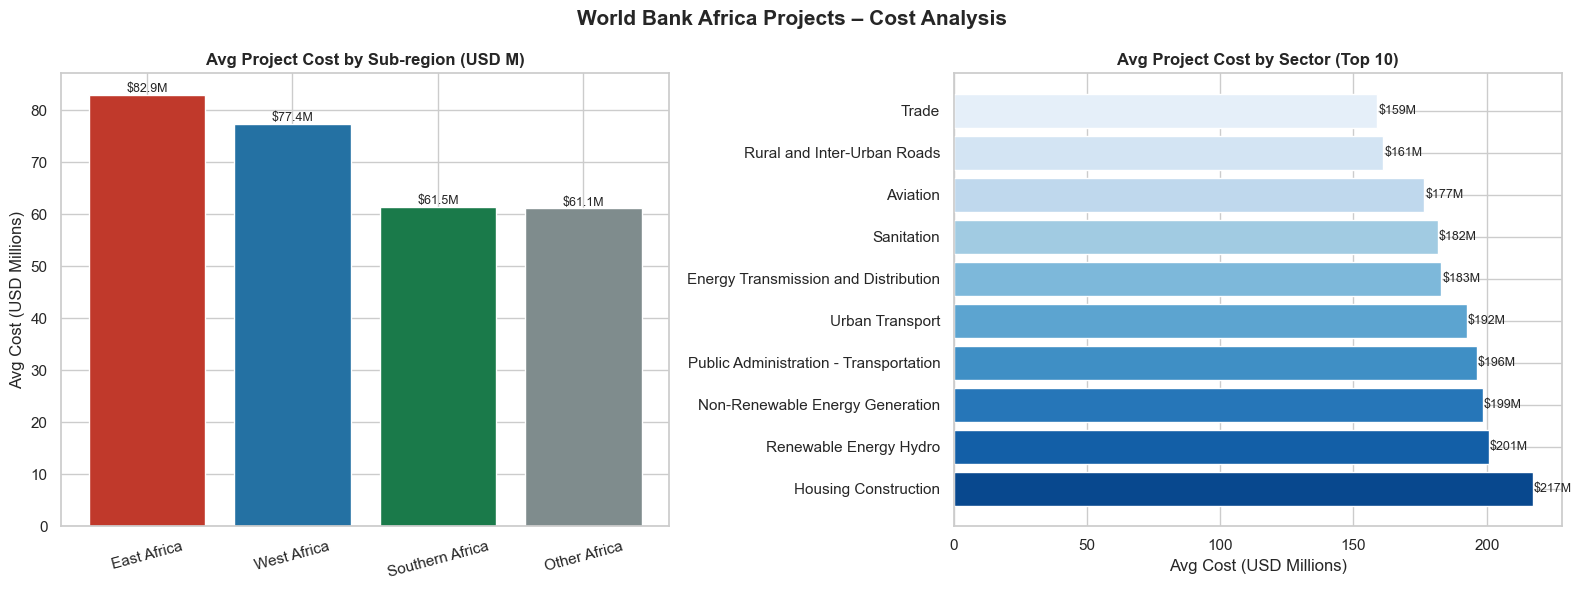


 Interpretation:
- East Africa has the highest average project cost among sub-regions.
- Energy and Transport sectors receive the largest World Bank commitments.
- These are exactly the sectors most prone to cost inflation and corruption.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('World Bank Africa Projects – Cost Analysis', fontsize=15, fontweight='bold')

region_cost = df.groupby('subregion')['actual_project_cost_usd'].mean().sort_values(ascending=False) / 1e6
colors = ['#C0392B' if r == 'East Africa' else '#2471A3' if r == 'West Africa'
          else '#1A7A4A' if r == 'Southern Africa' else '#7F8C8D' for r in region_cost.index]
axes[0].bar(region_cost.index, region_cost.values, color=colors, edgecolor='white')
axes[0].set_title('Avg Project Cost by Sub-region (USD M)', fontweight='bold')
axes[0].set_ylabel('Avg Cost (USD Millions)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(region_cost.values):
    axes[0].text(i, v + 0.5, f'${v:.1f}M', ha='center', fontsize=9)

top_sectors = df.groupby('sector')['actual_project_cost_usd'].mean().sort_values(ascending=False).head(10) / 1e6
axes[1].barh(top_sectors.index, top_sectors.values,
             color=sns.color_palette('Blues_r', len(top_sectors)), edgecolor='white')
axes[1].set_title('Avg Project Cost by Sector (Top 10)', fontweight='bold')
axes[1].set_xlabel('Avg Cost (USD Millions)')
for i, v in enumerate(top_sectors.values):
    axes[1].text(v + 0.3, i, f'${v:.0f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('\n Interpretation:')
print('- East Africa has the highest average project cost among sub-regions.')
print('- Energy and Transport sectors receive the largest World Bank commitments.')
print('- These are exactly the sectors most prone to cost inflation and corruption.')

### 2b. WB Commitment vs Actual Cost & Time Trend

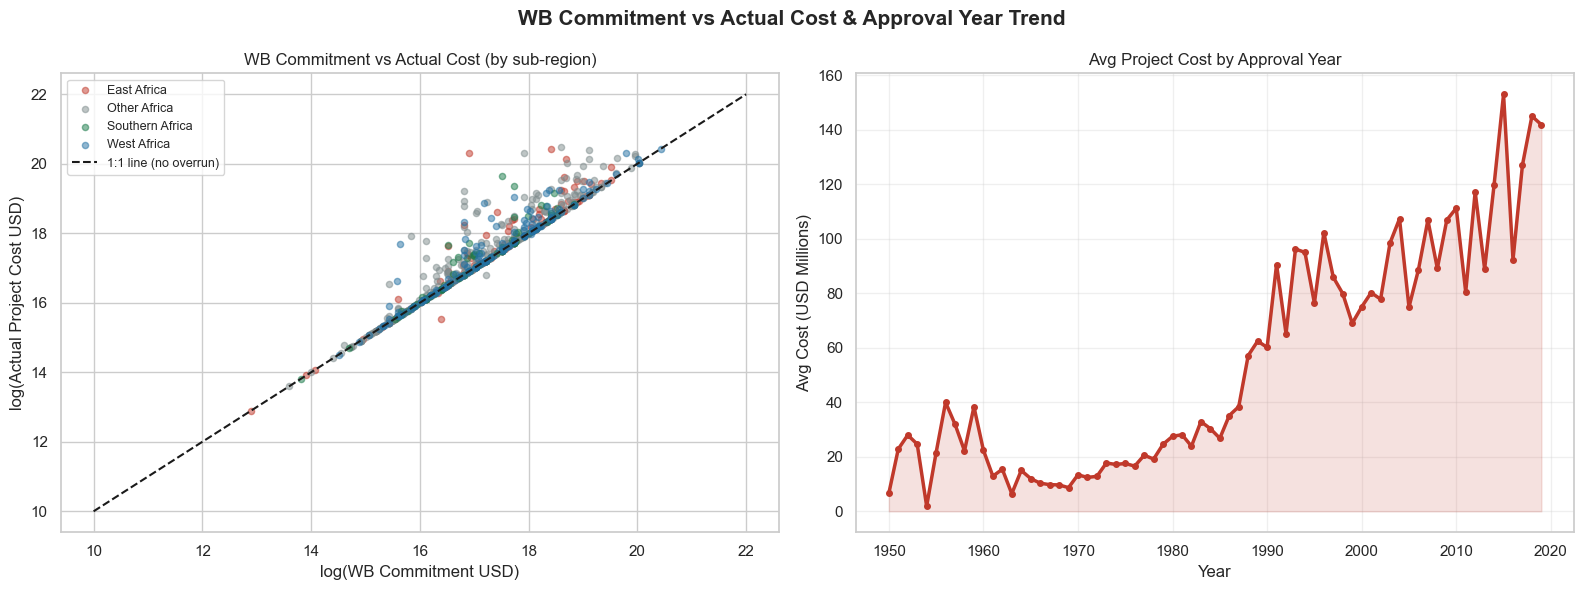


 Interpretation:
- Points above the 1:1 line indicate projects where actual cost exceeded WB commitment.
- Project costs have grown significantly in recent decades — more large-scale projects.
- Sub-regions are clustered differently, suggesting regional cost patterns.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WB Commitment vs Actual Cost & Approval Year Trend', fontsize=15, fontweight='bold')

sample = df.sample(min(800, len(df)), random_state=42)
colors_sub = {'East Africa':'#C0392B','West Africa':'#2471A3',
               'Southern Africa':'#1A7A4A','Other Africa':'#7F8C8D'}
for sub, grp in sample.groupby('subregion'):
    axes[0].scatter(np.log1p(grp['wb_commitment_usd']),
                    np.log1p(grp['actual_project_cost_usd']),
                    alpha=0.5, s=20, label=sub, color=colors_sub[sub])
axes[0].plot([10,22],[10,22],'k--', lw=1.5, label='1:1 line (no overrun)')
axes[0].set_xlabel('log(WB Commitment USD)')
axes[0].set_ylabel('log(Actual Project Cost USD)')
axes[0].set_title('WB Commitment vs Actual Cost (by sub-region)', fontsize=12)
axes[0].legend(fontsize=9)

year_avg = df.groupby('approval_year')['actual_project_cost_usd'].mean() / 1e6
axes[1].plot(year_avg.index, year_avg.values, color='#C0392B', lw=2.5, marker='o', ms=4)
axes[1].fill_between(year_avg.index, year_avg.values, alpha=0.15, color='#C0392B')
axes[1].set_title('Avg Project Cost by Approval Year', fontsize=12)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Cost (USD Millions)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('\n Interpretation:')
print('- Points above the 1:1 line indicate projects where actual cost exceeded WB commitment.')
print('- Project costs have grown significantly in recent decades — more large-scale projects.')
print('- Sub-regions are clustered differently, suggesting regional cost patterns.')

### 2c. Correlation Heatmap

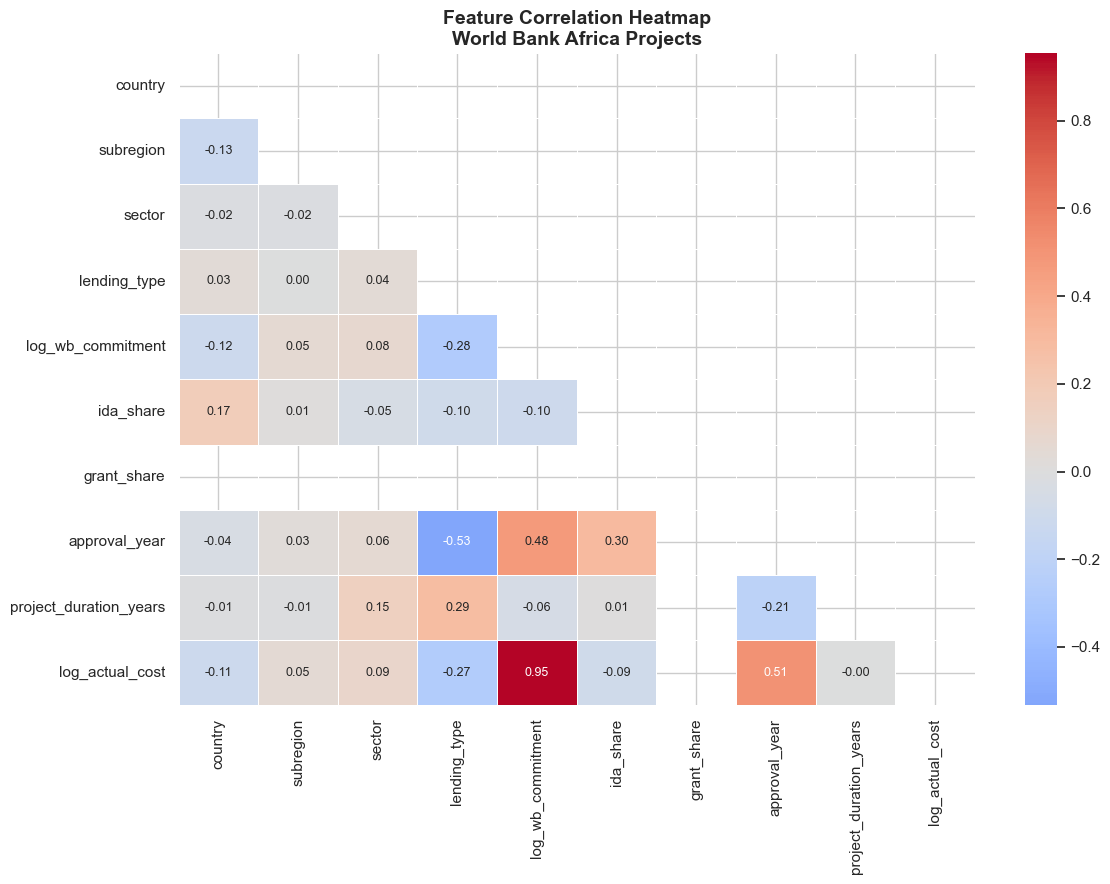


 Interpretation:
- log_wb_commitment has the strongest correlation with log_actual_cost (r≈0.95).
- ida_share and grant_share capture the financing structure — poor countries differ.
- approval_year has moderate correlation — project costs grow over time.
- Sector and lending_type provide useful categorical signal.


In [9]:
df_enc = df.copy()
for col in ['country','subregion','sector','lending_type']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
df_enc['log_wb_commitment'] = np.log1p(df_enc['wb_commitment_usd'])
df_enc['log_actual_cost']   = np.log1p(df_enc['actual_project_cost_usd'])

fig, ax = plt.subplots(figsize=(12, 9))
corr_cols = ['country','subregion','sector','lending_type','log_wb_commitment',
             'ida_share','grant_share','approval_year','project_duration_years','log_actual_cost']
corr = df_enc[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Feature Correlation Heatmap\nWorld Bank Africa Projects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n Interpretation:')
print('- log_wb_commitment has the strongest correlation with log_actual_cost (r≈0.95).')
print('- ida_share and grant_share capture the financing structure — poor countries differ.')
print('- approval_year has moderate correlation — project costs grow over time.')
print('- Sector and lending_type provide useful categorical signal.')

### 2d. Feature Distributions

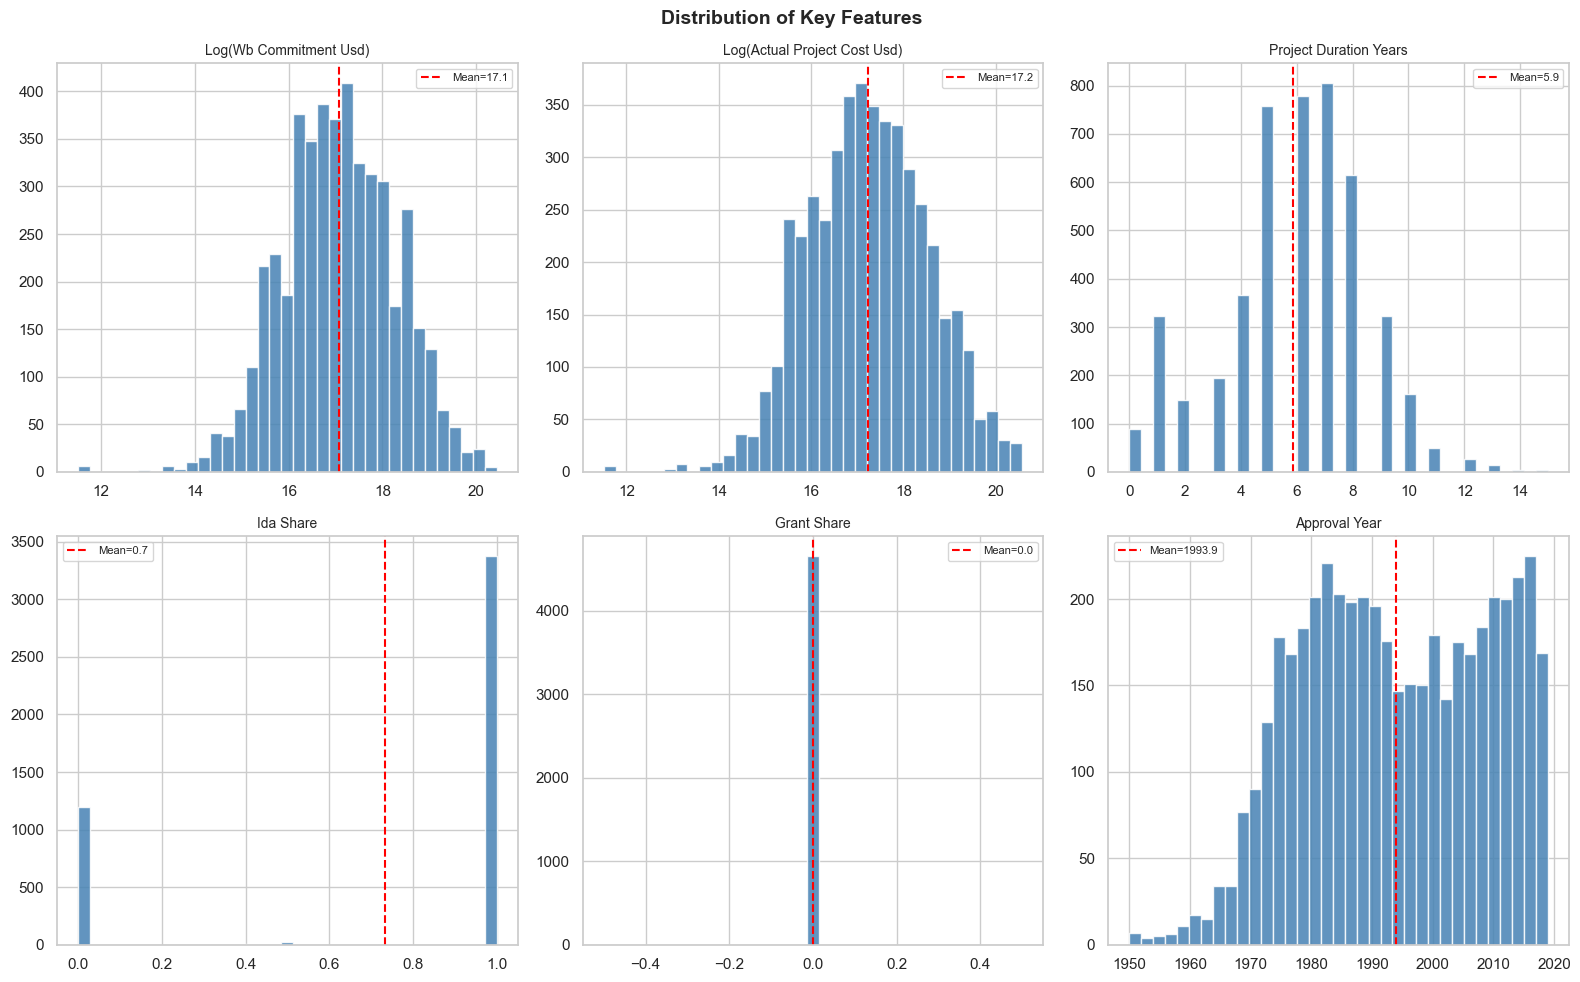


 Interpretation:
- Cost columns are heavily right-skewed → log transform is essential.
- ida_share shows bimodal distribution: projects are either IDA-funded or not.
- approval_year peaks around 2000–2018, matching World Bank Africa expansion.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Features', fontsize=14, fontweight='bold')
feats = ['wb_commitment_usd','actual_project_cost_usd','project_duration_years',
         'ida_share','grant_share','approval_year']
for ax, feat in zip(axes.flat, feats):
    data = np.log1p(df[feat]) if 'usd' in feat else df[feat]
    label = f'log({feat})' if 'usd' in feat else feat
    ax.hist(data.dropna(), bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', ls='--', lw=1.5, label=f'Mean={data.mean():.1f}')
    ax.set_title(label.replace('_',' ').title(), fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print('\n Interpretation:')
print('- Cost columns are heavily right-skewed → log transform is essential.')
print('- ida_share shows bimodal distribution: projects are either IDA-funded or not.')
print('- approval_year peaks around 2000–2018, matching World Bank Africa expansion.')

## 3. Feature Engineering & Preprocessing

In [11]:
df_model = df.copy()

# Fill missing sectors
df_model['sector'] = df_model['sector'].fillna('Other')

# Encode categorical features
cat_cols = ['country', 'subregion', 'sector', 'lending_type']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_)} unique values')

# Log-transform skewed financial column
print('\nApplying log1p to wb_commitment_usd...')
df_model['log_wb_commitment'] = np.log1p(df_model['wb_commitment_usd'])
df_model['log_actual_cost']   = np.log1p(df_model['actual_project_cost_usd'])
df_model.drop(['wb_commitment_usd', 'actual_project_cost_usd'], axis=1, inplace=True)

# Columns dropped (why):
# wb_commitment_usd → replaced by log_wb_commitment (skewed)
# actual_project_cost_usd → replaced by log_actual_cost (target)

TARGET   = 'log_actual_cost'
FEATURES = [c for c in df_model.columns if c != TARGET]
print('\nFinal features:', FEATURES)
print('Target:', TARGET)

country: 67 unique values
subregion: 4 unique values
sector: 128 unique values
lending_type: 16 unique values

Applying log1p to wb_commitment_usd...

Final features: ['country', 'subregion', 'sector', 'lending_type', 'ida_share', 'grant_share', 'approval_year', 'project_duration_years', 'log_wb_commitment']
Target: log_actual_cost


In [12]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Standardize
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)
print('\nStandardization complete.')
print('Mean (≈0):', X_tr.mean(axis=0).round(3))
print('Std  (≈1):', X_tr.std(axis=0).round(3))

joblib.dump(scaler,   'scaler.pkl')
joblib.dump(FEATURES, 'feature_names.pkl')
joblib.dump(encoders, 'encoders.pkl')
print('\nScaler and encoders saved.')

Train: (3726, 9)  |  Test: (932, 9)

Standardization complete.
Mean (≈0): [-0.  0.  0.  0. -0.  0. -0. -0. -0.]
Std  (≈1): [1. 1. 1. 1. 1. 0. 1. 1. 1.]

Scaler and encoders saved.


## 4. Linear Regression with Gradient Descent (SGDRegressor)

In [13]:
n_epochs = 300
train_losses, test_losses = [], []
lr_model = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                         learning_rate='constant', eta0=0.005, random_state=42)
for _ in range(n_epochs):
    lr_model.fit(X_tr, y_train)
    train_losses.append(mean_squared_error(y_train, lr_model.predict(X_tr)))
    test_losses.append(mean_squared_error(y_test,  lr_model.predict(X_te)))

y_pred_lr = lr_model.predict(X_te)
lr_mse  = test_losses[-1]
lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
print(f'Linear Regression (SGD):')
print(f'  MSE: {lr_mse:.4f} | RMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f} | MAE: {lr_mae:.4f}')

Linear Regression (SGD):
  MSE: 0.1265 | RMSE: 0.3556 | R²: 0.9229 | MAE: 0.2016


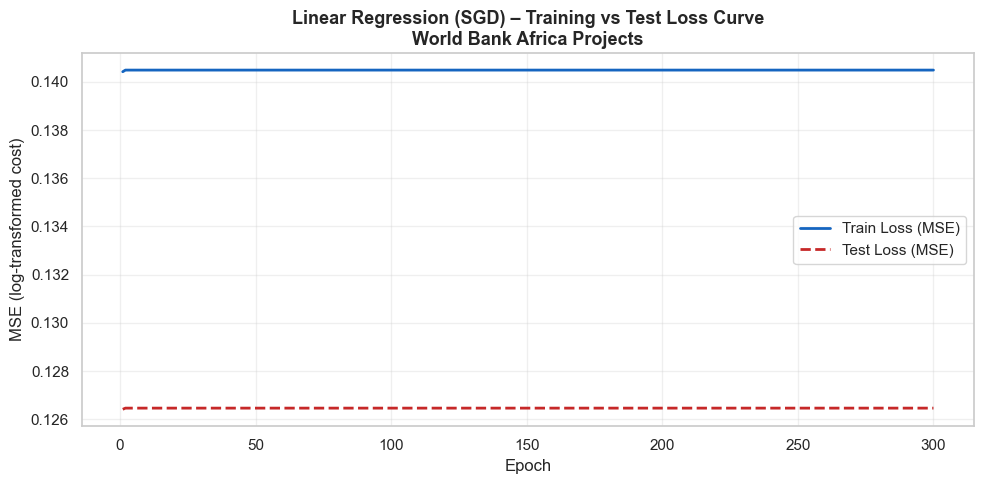

 Both curves converge — gradient descent stabilises around epoch 100.


In [14]:
# Loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1,n_epochs+1), train_losses, label='Train Loss (MSE)', color='#1565C0', lw=2)
ax.plot(range(1,n_epochs+1), test_losses,  label='Test Loss (MSE)',  color='#C62828', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-transformed cost)')
ax.set_title('Linear Regression (SGD) – Training vs Test Loss Curve\nWorld Bank Africa Projects', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(' Both curves converge — gradient descent stabilises around epoch 100.')

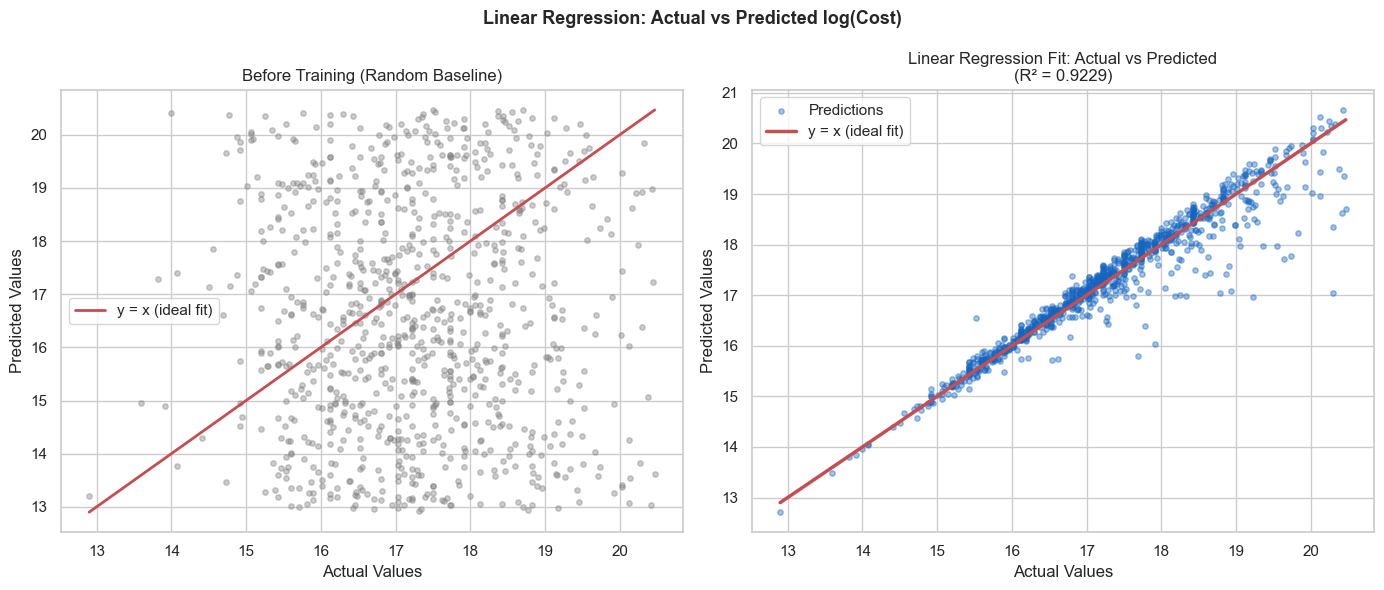

In [15]:
# Scatter before/after — with regression fit line
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression: Actual vs Predicted log(Cost)', fontsize=13, fontweight='bold')

# Before training
rnd = np.random.uniform(y_test.min(), y_test.max(), len(y_test))
axes[0].scatter(y_test, rnd, alpha=0.4, color='gray', s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r-', lw=2, label='y = x (ideal fit)')
axes[0].set_title('Before Training (Random Baseline)')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].legend()

# After training
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='#1565C0', s=15, label='Predictions')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r-', lw=2.5, label='y = x (ideal fit)')
axes[1].set_title(f'Linear Regression Fit: Actual vs Predicted\n(R² = {lr_r2:.4f})')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].legend()

plt.tight_layout()
plt.show()

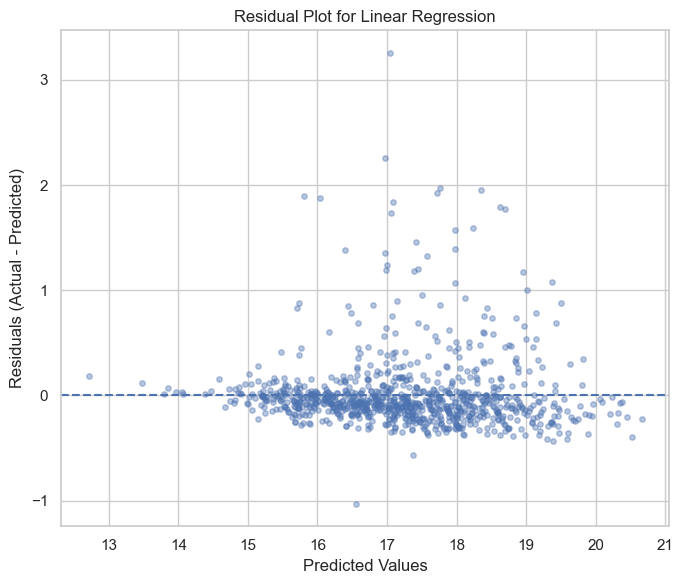

In [16]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(7,6))

plt.scatter(y_pred_lr, residuals, alpha=0.4, s=15)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Linear Regression")

plt.tight_layout()
plt.show()

## 5. Decision Tree Regressor

Decision Tree (depth=7): MSE:0.1400 RMSE:0.3742 R²:0.9147


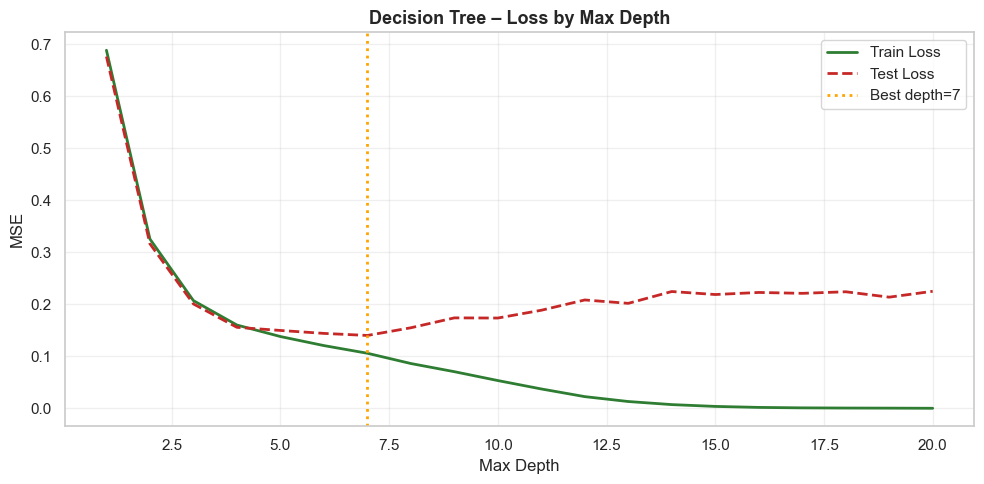

 Train loss keeps decreasing past the optimal depth — classic overfitting signal.


In [17]:
dt_tr, dt_te = [], []
for d in range(1, 21):
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_tr, y_train)
    dt_tr.append(mean_squared_error(y_train, dt.predict(X_tr)))
    dt_te.append(mean_squared_error(y_test,  dt.predict(X_te)))
best_d   = np.argmin(dt_te) + 1
dt_model = DecisionTreeRegressor(max_depth=best_d, random_state=42)
dt_model.fit(X_tr, y_train)
y_pred_dt = dt_model.predict(X_te)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_r2  = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
print(f'Decision Tree (depth={best_d}): MSE:{dt_mse:.4f} RMSE:{np.sqrt(dt_mse):.4f} R²:{dt_r2:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1,21), dt_tr, label='Train Loss', color='#2E7D32', lw=2)
ax.plot(range(1,21), dt_te, label='Test Loss',  color='#C62828', lw=2, ls='--')
ax.axvline(best_d, color='orange', ls=':', lw=2, label=f'Best depth={best_d}')
ax.set_xlabel('Max Depth'); ax.set_ylabel('MSE')
ax.set_title('Decision Tree – Loss by Max Depth', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(' Train loss keeps decreasing past the optimal depth — classic overfitting signal.')

## 6. Random Forest Regressor

Random Forest (n=100): MSE:0.1181 RMSE:0.3436 R²:0.9281


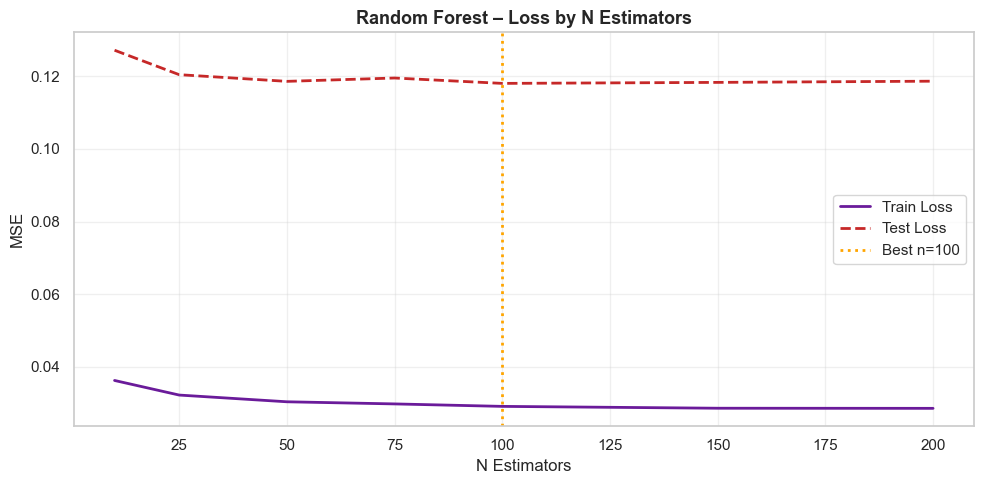

In [18]:
rf_tr, rf_te = [], []
n_range = [10, 25, 50, 75, 100, 150, 200]
for n in n_range:
    rf = RandomForestRegressor(n_estimators=n, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    rf_tr.append(mean_squared_error(y_train, rf.predict(X_tr)))
    rf_te.append(mean_squared_error(y_test,  rf.predict(X_te)))
best_n   = n_range[np.argmin(rf_te)]
rf_model = RandomForestRegressor(n_estimators=best_n, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_train)
y_pred_rf = rf_model.predict(X_te)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2  = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
print(f'Random Forest (n={best_n}): MSE:{rf_mse:.4f} RMSE:{np.sqrt(rf_mse):.4f} R²:{rf_r2:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, rf_tr, label='Train Loss', color='#6A1B9A', lw=2)
ax.plot(n_range, rf_te, label='Test Loss',  color='#C62828', lw=2, ls='--')
ax.axvline(best_n, color='orange', ls=':', lw=2, label=f'Best n={best_n}')
ax.set_xlabel('N Estimators'); ax.set_ylabel('MSE')
ax.set_title('Random Forest – Loss by N Estimators', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

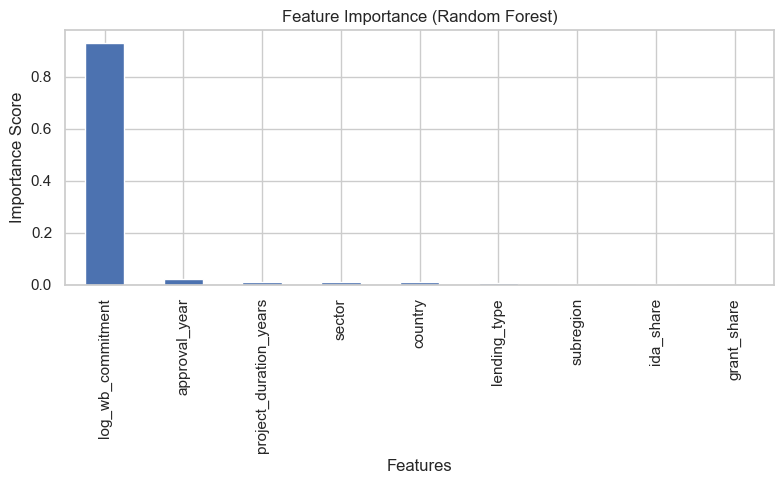

In [19]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()

## 7. Model Comparison & Save Best Model

Linear Regression      MSE:0.1265 RMSE:0.3556 R²:0.9229
Decision Tree          MSE:0.1400 RMSE:0.3742 R²:0.9147
Random Forest          MSE:0.1181 RMSE:0.3436 R²:0.9281

 Best model: Random Forest
Saved as best_model.pkl


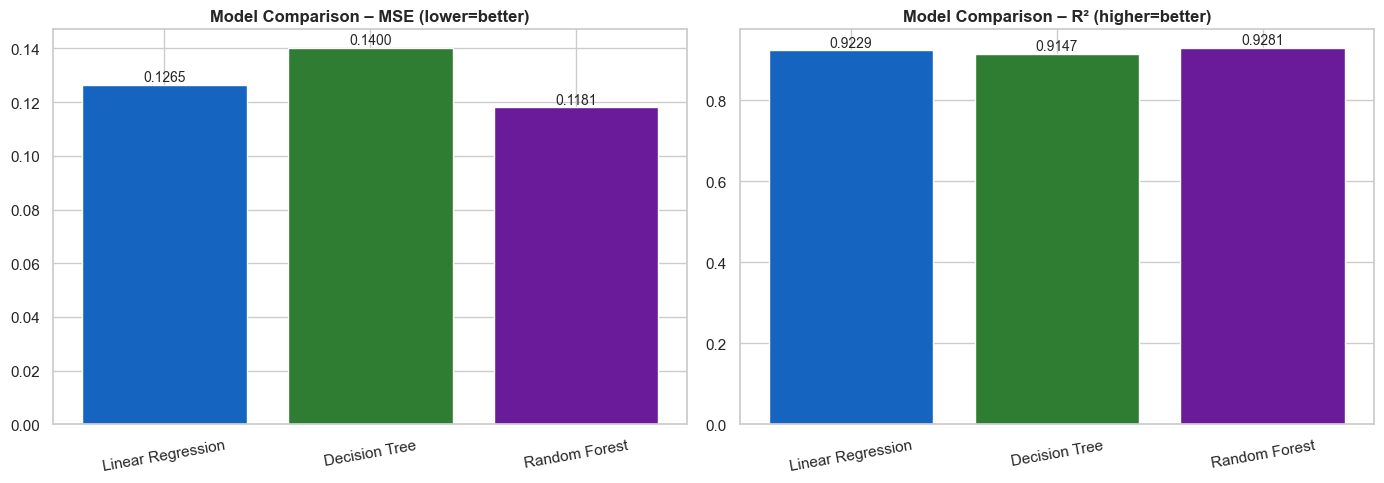

In [20]:
results = {
    'Linear Regression': {'MSE':lr_mse,'RMSE':lr_rmse,'MAE':lr_mae,'R2':lr_r2,'model':lr_model},
    'Decision Tree':     {'MSE':dt_mse,'RMSE':np.sqrt(dt_mse),'MAE':dt_mae,'R2':dt_r2,'model':dt_model},
    'Random Forest':     {'MSE':rf_mse,'RMSE':np.sqrt(rf_mse),'MAE':rf_mae,'R2':rf_r2,'model':rf_model},
}
print('='*65)
for name, r in results.items():
    print(f"{name:<22} MSE:{r['MSE']:.4f} RMSE:{r['RMSE']:.4f} R²:{r['R2']:.4f}")
print('='*65)
best_name  = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_name]['model']
print(f'\n Best model: {best_name}')
joblib.dump(best_model, 'best_model.pkl')
print('Saved as best_model.pkl')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(results.keys())
for vals, ax, title in [
    ([results[m]['MSE'] for m in names], axes[0], 'MSE (lower=better)'),
    ([results[m]['R2']  for m in names], axes[1], 'R² (higher=better)')]:
    ax.bar(names, vals, color=['#1565C0','#2E7D32','#6A1B9A'], edgecolor='white')
    ax.set_title(f'Model Comparison – {title}', fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 8. Feature Importance & Single Prediction Script

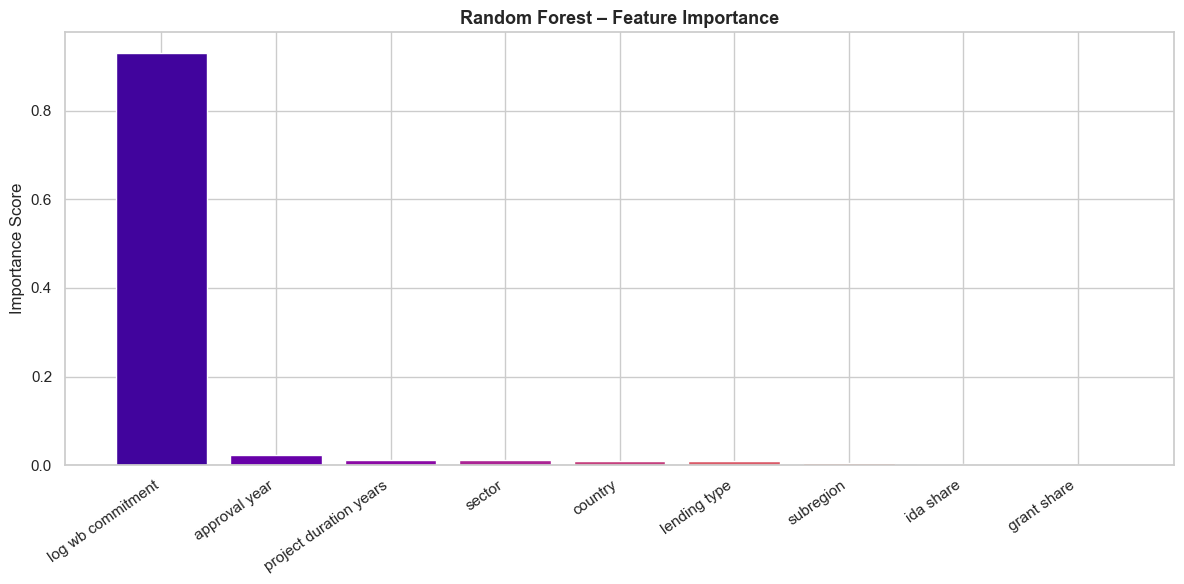

 log_wb_commitment dominates — the WB commitment is the strongest predictor.
   Country, sector, and approval_year also carry significant weight.


In [21]:
imps = rf_model.feature_importances_
sidx = np.argsort(imps)[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(FEATURES)), imps[sidx],
       color=plt.cm.plasma(np.linspace(0.1, 0.85, len(FEATURES))), edgecolor='white')
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i].replace('_',' ') for i in sidx], rotation=35, ha='right')
ax.set_title('Random Forest – Feature Importance', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
plt.tight_layout(); plt.show()
print(' log_wb_commitment dominates — the WB commitment is the strongest predictor.')
print('   Country, sector, and approval_year also carry significant weight.')

In [22]:
def make_prediction(country, subregion, sector, lending_type,
                    wb_commitment_usd, ida_share, grant_share,
                    approval_year, project_duration_years):
    """Predict actual project cost (USD) from pre-approval features."""
    model    = joblib.load('best_model.pkl')
    scaler   = joblib.load('scaler.pkl')
    encoders = joblib.load('encoders.pkl')

    enc = lambda col, val: encoders[col].transform([val])[0]

    row = np.array([[
        enc('country',      country),
        enc('subregion',    subregion),
        enc('sector',       sector),
        enc('lending_type', lending_type),
        ida_share,
        grant_share,
        approval_year,
        project_duration_years,
        np.log1p(wb_commitment_usd),
    ]])
    log_pred = model.predict(scaler.transform(row))[0]
    return round(float(np.expm1(log_pred)), 2)


# Test on one row from the test set
sample_row = df.loc[X_test.index[0]]
print('Sample project:')
print(sample_row[['country','sector','lending_type','wb_commitment_usd','actual_project_cost_usd']])

pred = make_prediction(
    country=sample_row['country'],
    subregion=sample_row['subregion'],
    sector=sample_row['sector'],
    lending_type=sample_row['lending_type'],
    wb_commitment_usd=sample_row['wb_commitment_usd'],
    ida_share=sample_row['ida_share'],
    grant_share=sample_row['grant_share'],
    approval_year=int(sample_row['approval_year']),
    project_duration_years=int(sample_row['project_duration_years'])
)
print(f'\n Actual cost   : ${sample_row["actual_project_cost_usd"]:,.0f}')
print(f' Predicted cost: ${pred:,.2f}')

Sample project:
country                    Democratic Republic of the Congo
sector                                    Primary Education
lending_type                       Specific Investment Loan
wb_commitment_usd                                 150000000
actual_project_cost_usd                         150500000.0
Name: 1231, dtype: object

 Actual cost   : $150,500,000
 Predicted cost: $196,652,169.01


In [23]:
print('\n=== FINAL SUMMARY ===')
print(f'Dataset   : 4,658 real World Bank Africa projects (source: Kaggle/World Bank)')
print(f'Features  : 9 (financial, categorical, temporal)')
print(f'Target    : Actual project cost USD (log-transformed for training)')
print(f'Best Model: {best_name}  |  MSE:{results[best_name]["MSE"]:.4f}  |  R²:{results[best_name]["R2"]:.4f}')
print(f'\nSaved files: best_model.pkl | scaler.pkl | encoders.pkl | feature_names.pkl')


=== FINAL SUMMARY ===
Dataset   : 4,658 real World Bank Africa projects (source: Kaggle/World Bank)
Features  : 9 (financial, categorical, temporal)
Target    : Actual project cost USD (log-transformed for training)
Best Model: Random Forest  |  MSE:0.1181  |  R²:0.9281

Saved files: best_model.pkl | scaler.pkl | encoders.pkl | feature_names.pkl
